In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as scikit_learn
import xgboost as xgb
%matplotlib inline

In [2]:
df=pd.read_csv("DATA/demand_forecasting.csv")

In [3]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [5]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [6]:
df['Date']=pd.to_datetime(df['Date'])

In [7]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday
df['Weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
# df['Is_weekend'] = df['Weekday'].isin([5,6]).astype(int)

In [8]:
# sorting data w.r.t date
df=df.sort_values(by='Date')

In [9]:
df.drop('Date',axis=1,inplace=True)

In [10]:
# creating Lag feture
df['lag_1_demand'] = df['Demand'].shift(1)
df['lag_7_demand'] = df['Demand'].shift(7)
df['lag_30_demand'] = df['Demand'].shift(30)

df['lag_7_units_sold'] = df['Units Sold'].shift(7)
df['lag_30_units_sold'] = df['Units Sold'].shift(30)

df['lag_7_units_ordered'] = df['Units Ordered'].shift(7)

In [11]:
#  ROlling Mean(is the average of previous N values.)used in my project to smooth data and show trend
# rooling mean improves model accuracy
df['Rolling_Mean_7']=df['Demand'].rolling(window=7).mean()
df['Rolling_Mean_30']=df['Demand'].rolling(window=30).mean()


In [12]:
df.isnull().sum()

Store ID                0
Product ID              0
Category                0
Region                  0
Inventory Level         0
Units Sold              0
Units Ordered           0
Price                   0
Discount                0
Weather Condition       0
Promotion               0
Competitor Pricing      0
Seasonality             0
Epidemic                0
Demand                  0
Year                    0
Month                   0
Day                     0
Weekday                 0
Weekofyear              0
Quarter                 0
lag_1_demand            1
lag_7_demand            7
lag_30_demand          30
lag_7_units_sold        7
lag_30_units_sold      30
lag_7_units_ordered     7
Rolling_Mean_7          6
Rolling_Mean_30        29
dtype: int64

In [13]:
df=df.dropna()

In [14]:
df.columns

Index(['Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level',
       'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition',
       'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand',
       'Year', 'Month', 'Day', 'Weekday', 'Weekofyear', 'Quarter',
       'lag_1_demand', 'lag_7_demand', 'lag_30_demand', 'lag_7_units_sold',
       'lag_30_units_sold', 'lag_7_units_ordered', 'Rolling_Mean_7',
       'Rolling_Mean_30'],
      dtype='str')

In [15]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [16]:
df.head()
# df.info()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Weekofyear,Quarter,lag_1_demand,lag_7_demand,lag_30_demand,lag_7_units_sold,lag_30_units_sold,lag_7_units_ordered,Rolling_Mean_7,Rolling_Mean_30
95,S005,P0016,Toys,North,131,59,191,32.84,0,Snowy,0,39.50,Winter,0,76,2022,1,1,5,52,1,88.0,71.0,115.0,74.0,102.0,218.0,79.285714,93.066667
94,S005,P0015,Groceries,North,132,108,203,44.36,10,Snowy,0,52.84,Winter,0,93,2022,1,1,5,52,1,76.0,85.0,110.0,65.0,104.0,0.0,80.428571,92.500000
93,S005,P0014,Furniture,North,193,63,219,161.18,10,Snowy,1,156.66,Winter,0,82,2022,1,1,5,52,1,93.0,67.0,103.0,64.0,111.0,0.0,82.571429,91.800000
92,S005,P0013,Groceries,North,145,82,328,71.03,10,Snowy,0,78.02,Winter,0,116,2022,1,1,5,52,1,82.0,104.0,61.0,79.0,60.0,105.0,84.285714,93.633333
91,S005,P0012,Furniture,North,230,71,371,133.86,5,Snowy,0,118.20,Winter,0,84,2022,1,1,5,52,1,116.0,47.0,128.0,42.0,120.0,0.0,89.571429,92.166667


In [17]:
# df['Weather Condition']df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 75970 entries, 95 to 75999
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store ID             75970 non-null  str    
 1   Product ID           75970 non-null  str    
 2   Category             75970 non-null  str    
 3   Region               75970 non-null  str    
 4   Inventory Level      75970 non-null  int64  
 5   Units Sold           75970 non-null  int64  
 6   Units Ordered        75970 non-null  int64  
 7   Price                75970 non-null  float64
 8   Discount             75970 non-null  int64  
 9   Weather Condition    75970 non-null  str    
 10  Promotion            75970 non-null  int64  
 11  Competitor Pricing   75970 non-null  float64
 12  Seasonality          75970 non-null  str    
 13  Epidemic             75970 non-null  int64  
 14  Demand               75970 non-null  int64  
 15  Year                 75970 non-null  int32  
 16  M

In [18]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Region']=le.fit_transform(df['Region'])
# df["Weather Condition"]=le.fit_transform(df['Weather Condition'])
df['Seasonality']=le.fit_transform(df['Seasonality'])
df['Category']=le.fit_transform(df['Category'])
df['Promotion']=le.fit_transform(df['Promotion'])
df['Store ID']=le.fit_transform(df['Store ID'])
df['Product ID']=le.fit_transform(df["Product ID"])


In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 75970 entries, 95 to 75999
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store ID             75970 non-null  int64  
 1   Product ID           75970 non-null  int64  
 2   Category             75970 non-null  int64  
 3   Region               75970 non-null  int64  
 4   Inventory Level      75970 non-null  int64  
 5   Units Sold           75970 non-null  int64  
 6   Units Ordered        75970 non-null  int64  
 7   Price                75970 non-null  float64
 8   Discount             75970 non-null  int64  
 9   Weather Condition    75970 non-null  str    
 10  Promotion            75970 non-null  int64  
 11  Competitor Pricing   75970 non-null  float64
 12  Seasonality          75970 non-null  int64  
 13  Epidemic             75970 non-null  int64  
 14  Demand               75970 non-null  int64  
 15  Year                 75970 non-null  int32  
 16  M

In [20]:
# one hot encoding
df = pd.get_dummies(df, columns=['Weather Condition'], drop_first=True)

In [21]:
weather_cols = [col for col in df.columns if 'Weather Condition' in col]


In [22]:
features = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Inventory Level',
    'Price',
    'Discount',
    'Promotion',
    'Competitor Pricing',
    'Seasonality',
    'Epidemic',
    'Month',
    'Weekday',
    'Weekofyear',
    'Quarter',
    'lag_1_demand',
    'lag_7_demand',
    'lag_30_demand',
    'lag_7_units_sold',
    'lag_30_units_sold',
    'lag_7_units_ordered',
    'Rolling_Mean_7',
    'Rolling_Mean_30'
] + weather_cols


In [23]:
X = df[features]
y = df['Demand']

In [24]:
print(X.isnull().sum())


Store ID                   0
Product ID                 0
Category                   0
Region                     0
Inventory Level            0
Price                      0
Discount                   0
Promotion                  0
Competitor Pricing         0
Seasonality                0
Epidemic                   0
Month                      0
Weekday                    0
Weekofyear                 0
Quarter                    0
lag_1_demand               0
lag_7_demand               0
lag_30_demand              0
lag_7_units_sold           0
lag_30_units_sold          0
lag_7_units_ordered        0
Rolling_Mean_7             0
Rolling_Mean_30            0
Weather Condition_Rainy    0
Weather Condition_Snowy    0
Weather Condition_Sunny    0
dtype: int64


In [25]:
# List of original columns to drop
cols_to_drop = ['Units Sold', 'Units Ordered']

# Drop them from your feature set
X = df.drop(columns=cols_to_drop + ['Demand'])  # also drop target from features

# Target variable
y = df['Demand']

In [ ]:
df = df.dropna()
X = df[features]
y = np.log1p(df['Demand'])

In [27]:
X =X.astype(float)
y=y.astype(float)

In [28]:
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test=train_test_split(X ,y,test_size=0.35,random_state=42)

In [29]:
x_train.shape

(49380, 26)

In [30]:
# feture selection
x_train.info()

<class 'pandas.DataFrame'>
Index: 49380 entries, 26251 to 15876
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Store ID                 49380 non-null  float64
 1   Product ID               49380 non-null  float64
 2   Category                 49380 non-null  float64
 3   Region                   49380 non-null  float64
 4   Inventory Level          49380 non-null  float64
 5   Price                    49380 non-null  float64
 6   Discount                 49380 non-null  float64
 7   Promotion                49380 non-null  float64
 8   Competitor Pricing       49380 non-null  float64
 9   Seasonality              49380 non-null  float64
 10  Epidemic                 49380 non-null  float64
 11  Month                    49380 non-null  float64
 12  Weekday                  49380 non-null  float64
 13  Weekofyear               49380 non-null  float64
 14  Quarter                  49380 non

In [31]:
df.isnull().sum()

Store ID                   0
Product ID                 0
Category                   0
Region                     0
Inventory Level            0
Units Sold                 0
Units Ordered              0
Price                      0
Discount                   0
Promotion                  0
Competitor Pricing         0
Seasonality                0
Epidemic                   0
Demand                     0
Year                       0
Month                      0
Day                        0
Weekday                    0
Weekofyear                 0
Quarter                    0
lag_1_demand               0
lag_7_demand               0
lag_30_demand              0
lag_7_units_sold           0
lag_30_units_sold          0
lag_7_units_ordered        0
Rolling_Mean_7             0
Rolling_Mean_30            0
Weather Condition_Rainy    0
Weather Condition_Snowy    0
Weather Condition_Sunny    0
dtype: int64

In [32]:
df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Weekofyear,Quarter,lag_1_demand,lag_7_demand,lag_30_demand,lag_7_units_sold,lag_30_units_sold,lag_7_units_ordered,Rolling_Mean_7,Rolling_Mean_30,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny
95,4,15,4,1,131,59,191,32.84,0,0,39.50,3,0,76,2022,1,1,5,52,1,88.0,71.0,115.0,74.0,102.0,218.0,79.285714,93.066667,False,True,False
94,4,14,3,1,132,108,203,44.36,10,0,52.84,3,0,93,2022,1,1,5,52,1,76.0,85.0,110.0,65.0,104.0,0.0,80.428571,92.500000,False,True,False
93,4,13,2,1,193,63,219,161.18,10,1,156.66,3,0,82,2022,1,1,5,52,1,93.0,67.0,103.0,64.0,111.0,0.0,82.571429,91.800000,False,True,False
92,4,12,3,1,145,82,328,71.03,10,0,78.02,3,0,116,2022,1,1,5,52,1,82.0,104.0,61.0,79.0,60.0,105.0,84.285714,93.633333,False,True,False
91,4,11,2,1,230,71,371,133.86,5,0,118.20,3,0,84,2022,1,1,5,52,1,116.0,47.0,128.0,42.0,120.0,0.0,89.571429,92.166667,False,True,False


In [33]:
# df.drop('Date',inplace=True,axis=1)

In [34]:
# numeric_df=df.select_dtypes(include=['int64','float64'])
x_train.corr()

,Store ID,Product ID,Category,Region,Inventory Level,Price,Discount,Promotion,Competitor Pricing,Seasonality,Epidemic,Month,Weekday,Weekofyear,Quarter,lag_1_demand,lag_7_demand,lag_30_demand,lag_7_units_sold,lag_30_units_sold,lag_7_units_ordered,Rolling_Mean_7,Rolling_Mean_30,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny
Store ID,1.000000,-0.001515,0.072057,0.138899,-0.020718,-0.015108,0.008220,0.006733,-0.014734,-0.004429,0.000161,0.000813,-0.007068,-0.000451,0.000305,-0.026481,-0.013444,0.064516,-0.008642,0.060319,-0.001845,-0.026439,-0.013011,-0.003433,0.006737,0.011955
Product ID,-0.001515,1.000000,-0.141264,0.000431,-0.106426,0.312101,-0.006474,-0.000389,0.308556,-0.001519,0.002716,0.002012,-0.001559,0.002097,0.001807,-0.057881,0.026267,-0.034531,0.022581,-0.038542,0.014240,-0.105832,-0.002761,-0.001309,0.001672,-0.001062
Category,0.072057,-0.141264,1.000000,-0.189474,0.039225,-0.409878,0.005235,0.001461,-0.403881,-0.001080,0.002191,-0.002116,0.001874,-0.000982,-0.001154,0.048865,-0.028935,-0.025346,-0.022816,-0.022930,-0.008354,0.005720,-0.009875,0.007637,-0.003486,-0.003477
Region,0.138899,0.000431,-0.189474,1.000000,-0.004870,0.068194,0.001094,0.000679,0.068849,-0.003435,0.001757,0.001653,0.000057,0.000967,0.000847,-0.013861,0.007361,0.011646,0.005918,0.009815,-0.002576,0.010295,0.015879,-0.030607,-0.003502,0.031407
Inventory Level,-0.020718,-0.106426,0.039225,-0.004870,1.000000,-0.038295,0.000824,-0.005967,-0.036780,0.019518,-0.094808,0.011568,0.001939,0.009033,0.003858,0.008068,0.039906,0.052683,0.036270,0.048870,0.003608,0.098598,0.104802,0.006289,-0.004245,-0.000906
Price,-0.015108,0.312101,-0.409878,0.068194,-0.038295,1.000000,-0.096233,-0.046034,0.976628,0.006124,-0.089390,0.018012,-0.001664,0.018613,0.011845,0.031478,0.066913,0.042821,0.052285,0.042873,0.023122,0.038954,0.090268,-0.031548,-0.017633,0.039419
Discount,0.008220,-0.006474,0.005235,0.001094,0.000824,-0.096233,1.000000,0.783893,-0.094365,0.009366,-0.004641,-0.007254,0.013966,-0.016331,-0.006843,0.008392,0.011855,0.011510,0.010392,0.010824,0.011843,0.075541,0.050919,-0.003166,0.007598,-0.006676
Promotion,0.006733,-0.000389,0.001461,0.000679,-0.005967,-0.046034,0.783893,1.000000,-0.044304,0.010424,-0.000474,-0.009031,0.018308,-0.018990,-0.010028,0.009425,0.017430,0.017042,0.016481,0.014673,0.012493,0.096109,0.061404,-0.002288,0.010589,-0.010333
Competitor Pricing,-0.014734,0.308556,-0.403881,0.068849,-0.036780,0.976628,-0.094365,-0.044304,1.000000,0.006047,-0.089757,0.018300,0.000154,0.018728,0.012075,0.031526,0.065634,0.042844,0.051716,0.041727,0.023618,0.039792,0.091038,-0.030663,-0.016834,0.039819
Seasonality,-0.004429,-0.001519,-0.001080,-0.003435,0.019518,0.006124,0.009366,0.010424,0.006047,1.000000,0.031068,-0.426294,0.007830,-0.406437,-0.430009,0.033082,0.032056,0.033910,0.023110,0.024872,0.008040,0.061607,0.078674,-0.220641,0.132394,0.037714


In [35]:
# corr=numeric_df.corr()

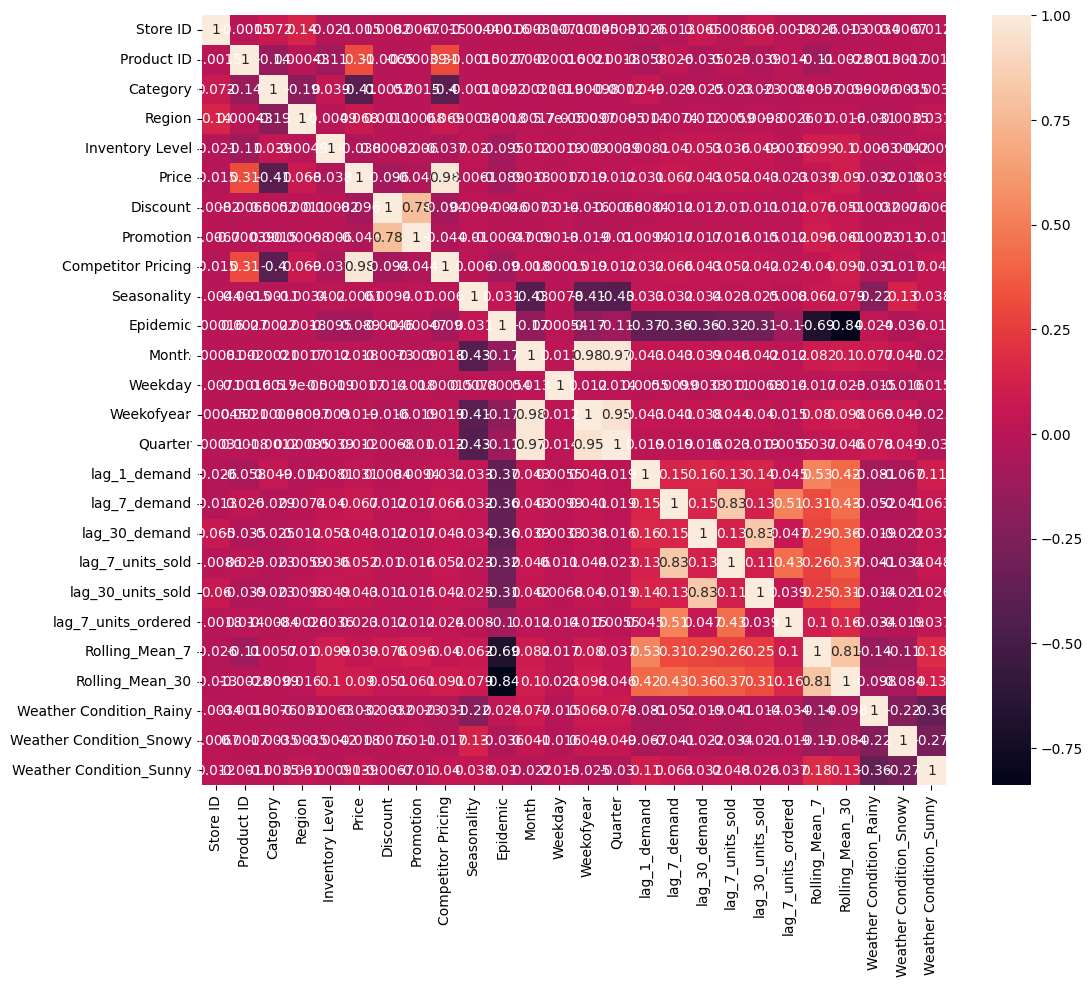

In [36]:
plt.figure(figsize=(12,10)) 
corr=x_train.corr()
sns.heatmap(corr,annot=True)

plt.show()

In [ ]:
# checking multicollinearty
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr            

    

In [38]:
# threshold domain expertise
corr_fetures=correlation(x_train,0.85)

In [39]:
corr_fetures

{'Competitor Pricing', 'Quarter', 'Weekofyear'}

In [40]:
# drop fetures when co-relation is more then 0.85
x_train.drop(corr_fetures,axis=1,inplace=True)
x_test.drop(corr_fetures,axis=1,inplace=True)

In [41]:
x_train.shape

(49380, 23)

In [42]:
# feture scaling or standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scale=scaler.fit_transform(x_train)
x_test_scale=scaler.transform(x_test)

In [43]:
x_train_scale

array([[ 0.00274636,  0.25982868, -0.18332177, ..., -0.54580449,
        -0.41187775,  1.5146604 ],
       [ 0.70907667, -0.43397513, -0.18332177, ..., -0.54580449,
        -0.41187775, -0.660214  ],
       [ 0.70907667, -1.12777894,  0.59211329, ..., -0.54580449,
         2.42790489, -0.660214  ],
       ...,
       [ 0.00274636,  1.12708345, -0.18332177, ..., -0.54580449,
        -0.41187775, -0.660214  ],
       [-0.70358395,  0.60673059, -0.95875683, ..., -0.54580449,
        -0.41187775, -0.660214  ],
       [ 0.70907667,  1.12708345, -1.73419189, ..., -0.54580449,
        -0.41187775, -0.660214  ]], shape=(49380, 23))

Text(0.5, 1.0, 'x_train after')

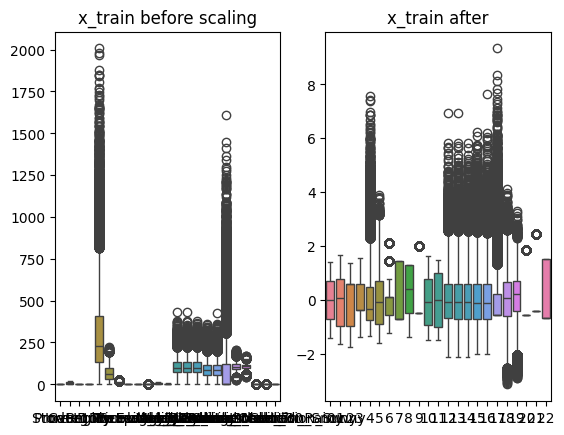

In [44]:
plt.Figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('x_train before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scale)
plt.title('x_train after')

In [45]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error,mean_squared_error
ligreg=LinearRegression()
ligreg.fit(x_train_scale,y_train)
y_pred=ligreg.predict(x_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

mean absulute error  29.116252923882858
r2_score 0.37722242370554415
mse 1374.8859629541462


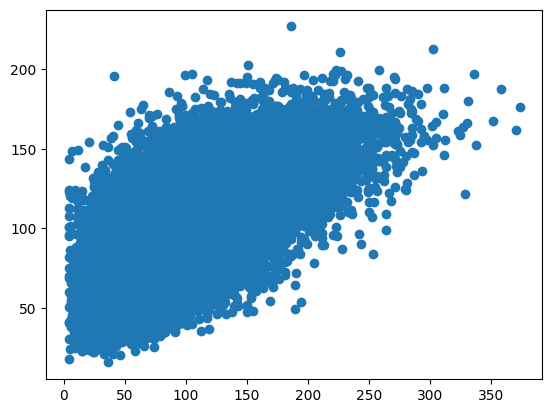

In [46]:
print("mean absulute error ",mae)
print("r2_score",score)
print("mse",mse)
plt.scatter(y_test,y_pred)

mean absulute error  29.28572897028603
r2_score 0.3712881981117713
mse 1387.9867613458082


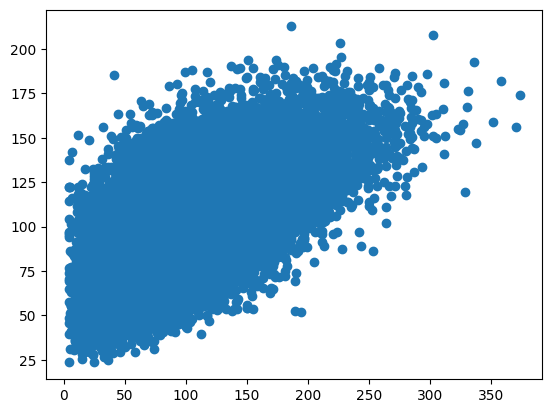

In [47]:
# Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(x_train_scale,y_train)
y_pred=lasso.predict(x_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
print("mean absulute error ",mae)
print("r2_score",score)
print('mse',mse)
plt.scatter(y_test,y_pred)


mean absulute error  29.116261376010282
r2_score 0.37722225586034674
mse 1387.9867613458082


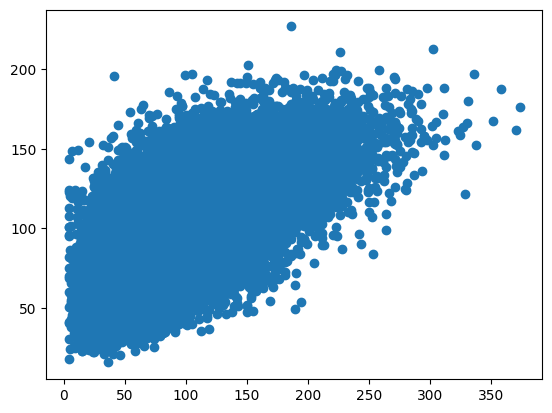

In [48]:
# ridge regression
# Lasso Regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score,mean_squared_error
ridge=Ridge()
ridge.fit(x_train_scale,y_train)
y_pred=ridge.predict(x_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)

print("mean absulute error ",mae)
print("r2_score",score)
print("mse",mse)
plt.scatter(y_test,y_pred)


mean absulute error  30.21142726784782
r2_score 0.33286993437037815
mse 1387.9867613458082


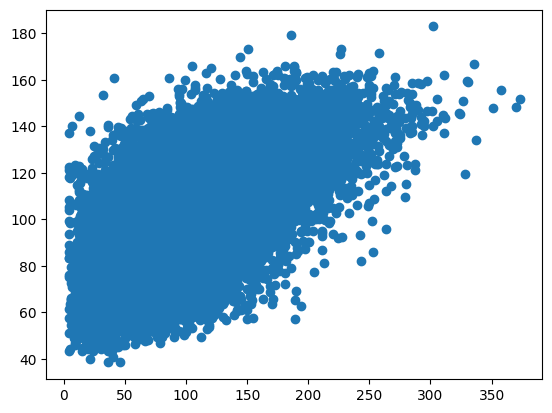

In [49]:
# Elasticnet Regression
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score,mean_squared_error
elastic=ElasticNet()
elastic.fit(x_train_scale,y_train)
y_pred=elastic.predict(x_test_scale)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)

print("mean absulute error ",mae)
print("r2_score",score)
print('mse',mse)
plt.scatter(y_test,y_pred)


In [50]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(x_train_scale, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [51]:
y_pred=model.predict(x_test_scale)
r_2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print("r2_score",r_2)
print("mean_absolute_error",mae)
print("root_mean_square_error",rmse)

r2_score 0.7010712276460352
mean_absolute_error 19.284178665823934
root_mean_square_error 25.689207979206678


23
23


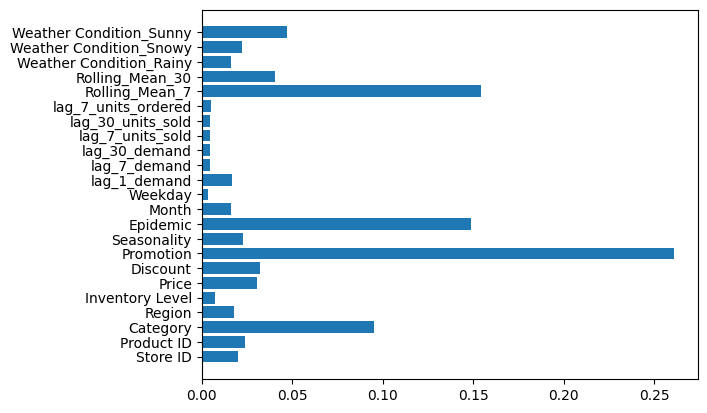

In [52]:
# feture importance (this tell which feture affect demand the most)
# If x_train_scale is a numpy array, recreate DataFrame to keep column names
X_scaled_df = pd.DataFrame(x_train_scale, columns=x_train.columns)
importance=model.feature_importances_
features=X_scaled_df.columns
print(len(features))
print(len(importance))
plt.Figure(figsize=(10,6))
plt.barh(features,importance)
plt.show()

In [53]:
# import pandas as pd
# import numpy as np
# from xgboost import XGBRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [54]:
# def evaluate_model(X, y, model_name):
    
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=0.2, random_state=42
#     )
    
#     model = XGBRegressor(
#         n_estimators=200,
#         learning_rate=0.05,
#         max_depth=6,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42
#     )
    
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
    
#     r2 = r2_score(y_test, y_pred)
#     mae = mean_absolute_error(y_test, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
#     print(f"\n{model_name}")
#     print("R2:", r2)
#     print("MAE:", mae)
#     print("RMSE:", rmse)
    
#     return r2, mae, rmse

In [55]:
# y=df["Demand"]

In [56]:
# # all fetures
# x1=df.drop(["Demand"],axis=1)
# r_2_1,mae_1,rmse_1=evaluate_model(x1,y,"model 1(all Features)")


In [57]:
# X2 = df.drop(["Demand", "Year", "Day", "Weekday","Store ID","Product ID"], axis=1)
# # we remove above things
# r2_2, mae_2, rmse_2 = evaluate_model(X2, y, "Model 2 (Removed Year, Day, Weekday,)")

In [58]:
# weather_cols = [col for col in df.columns if 'Weather' in col]
# print(weather_cols)

In [59]:
# X3 = df.drop(["Demand","Year", "Day", "Weekday", "Discount","Store ID","Product ID"], axis=1)

# r2_3, mae_3, rmse_3 = evaluate_model(X3, y, "Model 3 (More Features Removed)")

In [60]:
# results=pd.DataFrame({
#     "MOdel":["Model 1","Model 2","Model 3"],
#     "R2":[r_2_1,r2_2,r2_3],
#     "MAE":[mae_1,mae_2,mae_3],
#     "RMSE":[rmse_1,rmse_2,rmse_3]
# })
# print('final comparison:')
# print(results)

In [61]:
# x_new = df.drop([
#     "Demand",
#     "Units Sold",
#     "Units Ordered",
#     "Store ID",
#     "Product ID"
# ], axis=1)

In [62]:
# Model 1 is good(based on high r2 and low mae,rmse)
# now we are doing hyperparameter tunning
from sklearn.model_selection import GridSearchCV,TimeSeriesSplit
from xgboost import XGBRegressor
# time series crossvalidation(maintaning the order of time)
tscv=TimeSeriesSplit(n_splits=5)
# model
model=XGBRegressor(random_state=42)
param_grid={
    'n_estimators':[200,300],#hight of tree
    'max_depth':[4,6,8],
    'learning_rate':[0.03,0.05,0.1],
    'subsample':[0.8,1],
    'colsample_bytree':[0.8,1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 5]
}
# grid search
grid_search=GridSearchCV(estimator=model,param_grid=param_grid,cv=tscv,scoring='r2',n_jobs=-1,verbose=1)
# fit
grid_search.fit(x_train_scale,y_train)
# best parameter
print("bst parameter",grid_search.best_params_)
# bst model
best_model=grid_search.best_estimator_


  

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
bst parameter {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 5, 'subsample': 1}


In [63]:
# final model train
best_model.fit(x_train_scale,y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [64]:
# x_new = df.drop([
#     "Demand",
#     "Units Sold",
#     "Units Ordered",
#     "Store ID",
#     "Product ID"
# ], axis=1)

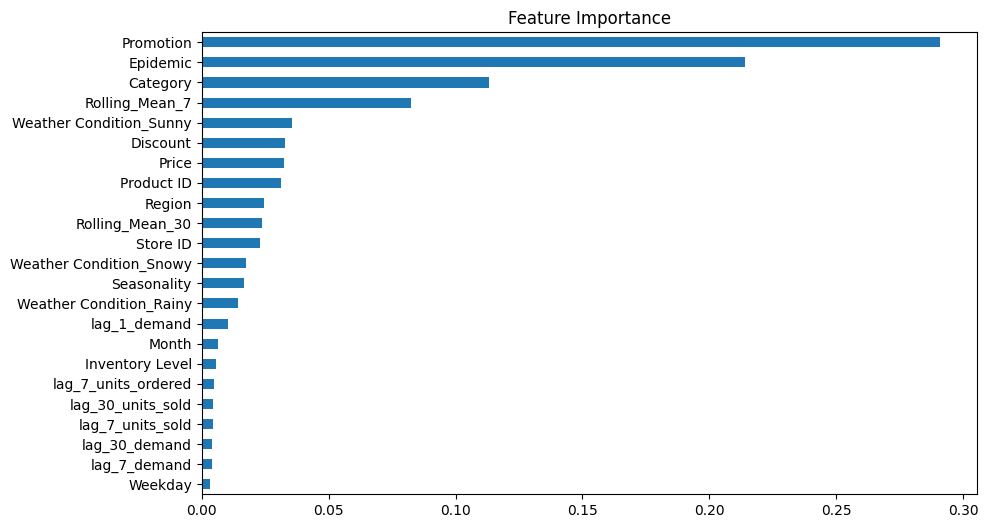

In [ ]:
# Convert scaled array to DataFrame
X_scaled_df = pd.DataFrame(x_train_scale, columns=x_train.columns)

# Feature importance
importance = best_model.feature_importances_
feat_imp = pd.Series(importance, index=X_scaled_df.columns)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(10,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [ ]:


# Train predictions
y_train_pred = best_model.predict(x_train_scale)

# Test predictions
y_test_pred = best_model.predict(x_test_scale)



In [3]:
# Train metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Test metrics
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R²: {r2_train}, MAE: {mae_train}, RMSE: {rmse_train}")
print(f"Test  R²: {r2_test}, MAE: {mae_test}, RMSE: {rmse_test}")

NameError: name 'y_train' is not defined

In [2]:
# evalute best model on test data
y_pred=best_model.predict(x_test_scale)
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

NameError: name 'best_model' is not defined

In [1]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,5))
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.show()

NameError: name 'y_test' is not defined

TypeError: expm1() takes from 1 to 2 positional arguments but 0 were given

New Shape: (75970, 18)
R2: 0.652305122778029
MAE: 19.408971706848327
RMSE: 25.995513660529884


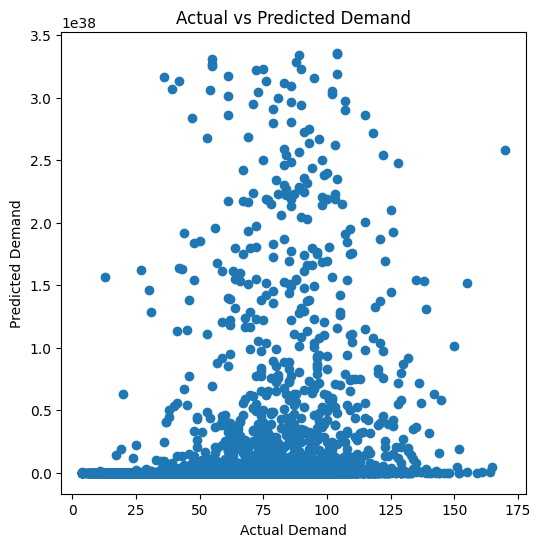

In [ ]:
# Convert back to original scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred_actual)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

# Perfect prediction line
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()])

plt.show()

C:\Users\DELL KING\AppData\Local\Temp\ipykernel_7552\112776729.py:1: RuntimeWarning: overflow encountered in expm1
  y_pred = np.expm1(y_pred)
